# SECOM Semiconductor Manufacturing Data - Exploratory Data Analysis

### Dataset Background

The SECOM dataset originates from a semiconductor fabrication facility where products undergo hundreds of sensor measurements during production. Each sample represents one production entity (e.g., a wafer or chip), and the binary label indicates whether the product passed or failed quality control.

| Attribute | Value |
|-----------|-------|
| **Samples** | 1,567 production entities |
| **Features** | 590 sensor measurements |
| **Labels** | Pass (-1) / Fail (1) |

### Key Questions This Analysis Addresses

1. How much missing data exists, and which features are most affected?
2. What is the class distribution (pass vs. fail)?
3. Which features show the strongest relationship with the outcome?
4. Are there redundant (highly correlated) features we can remove?
5. What preprocessing steps are needed before modeling?

***
## 1. Environment Setup and Data Loading

We begin by importing the necessary Python libraries and loading the dataset files. The SECOM data consists of two files:
- `secom.data`: Contains 590 sensor measurements per sample (space-separated, NaN for missing)
- `secom_labels.data`: Contains the pass/fail label and timestamp for each sample

In [3]:
# Load libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Suppress warnings
warnings.filterwarnings("ignore")

# Set visualization style for consistent, publication-quality plots
plt.style.use("seaborn-v0_8-whitegrid")


print("Libraries loaded successfully")

Libraries loaded successfully


# DATA LOADING

1. secom.data - Raw sensor measurements (590 features)
2. secom_labels.data - Pass/Fail labels with timestamps
3. Labels use -1 for Pass and 1 for Fail
4. 1 label column (pass/fail)
5. 1 timestamp column
6. Total: 592 columns

In [4]:
# DEFINE THE PATH TO THE DATA DIRECTORY
data_dir = Path("../data/secom")

# Load the sensor measurements (features)
df = pd.read_csv(
    data_dir / "secom.data",
    sep=" ",
    header=None,
    na_values="NaN",
)

# Assign meaningful column names (sensor_0, sensor_1, ..., sensor_589)
df.columns = [f"sensor_{i}" for i in range(df.shape[1])]

# Load the labels file containing pass/fail status and timestamps
labels = pd.read_csv(
    data_dir / "secom_labels.data",
    sep=" ",
    header=None,
    names=["label", "timestamp"],
)

# Merge labels into the main dataframe
df["label"] = labels["label"]

# Convert timestamp strings to proper datetime objects
# The strip('"') removes surrounding quotes from the timestamp strings
df["timestamp"] = pd.to_datetime(labels["timestamp"].str.strip('"'))

# Display dataset dimensions
print("Dataset Successfully Loaded")
print("=" * 40)
print(f"Total columns:             {df.shape[1]:,}")
print(f"  - Sensor features:       {df.shape[1] - 2}")
print(f"  - Additional columns:    label, timestamp")
print(f"Total rows (samples):      {df.shape[0]:,}")

Dataset Successfully Loaded
Total columns:             592
  - Sensor features:       590
  - Additional columns:    label, timestamp
Total rows (samples):      1,567


***
## 2. Data Overview

Before diving into detailed analysis, let's get a high-level view of the data structure, including data types, memory usage, and the time period over which the data was collected.

In [5]:
df.head()

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,2008-07-19 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,2008-07-19 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,2008-07-19 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 15:22:00


In [6]:
print("Data Types Summary")
print(df.dtypes.value_counts())



Data Types Summary
float64           590
int64               1
datetime64[ns]      1
Name: count, dtype: int64


# DATA COLLECTION TIME PERIOD
Understanding the time range helps us:
   - Identify if data represents seasonal/temporal patterns
   - Check for time-based drift in manufacturing process
   - Adjust rain/test splits if needed

In [7]:
print("Data Collection Period")
print(f"Start date: {df['timestamp'].min()}")
print(f"End date:   {df['timestamp'].max()}")
print(f"Duration:   {(df['timestamp'].max() - df['timestamp'].min()).days} days")

Data Collection Period
Start date: 2008-07-19 11:55:00
End date:   2008-10-17 06:07:00
Duration:   89 days


***
## 3. Missing Value Analysis

Missing values are common in manufacturing sensor data due to:
- Sensor malfunctions or calibration issues
- Data transmission errors
- Certain sensors not being applicable for all product types

In [8]:
# Calculate both absolute counts and percentages to understand:
# Which features have the most missing data
# How severe the missing data problem is overall

feature_cols = [col for col in df.columns if col.startswith("sensor_")]

#Count missing values for each feature
missing_counts = df[feature_cols].isnull().sum()

#Calculate missing percentage
missing_pct = (missing_counts / len(df)) * 100

#Summary dataframe sorted by missing percentage
missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct,
}).sort_values("missing_pct", ascending=False)

#Print summary statistics
print("Missing Value Summary")
print(f"Total sensor features:           {len(feature_cols)}")
print(f"Features with ANY missing:       {(missing_counts > 0).sum()}")
print(f"Features with >50% missing:      {(missing_pct > 50).sum()}")
print(f"Features 100% missing (useless): {(missing_pct == 100).sum()}")

Missing Value Summary
Total sensor features:           590
Features with ANY missing:       538
Features with >50% missing:      28
Features 100% missing (useless): 0


# VISUALIZE MISSING VALUE DISTRIBUTION
Two plots help us understand the missing data pattern:
1. Histogram: Shows the overall distribution of missingness
2. Bar chart: Highlights the worst offending features

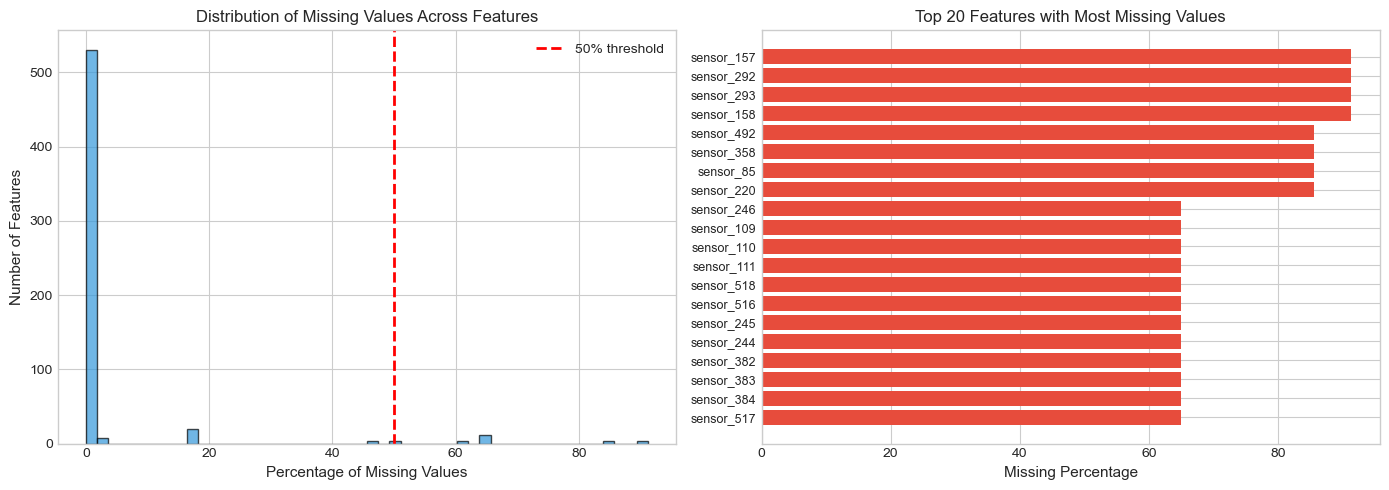

In [9]:
#Create two plots to show missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT PLOT: Histogram of missing percentages across all features
# This shows how many features fall into each "missingness" bucket
axes[0].hist(missing_pct, bins=50, edgecolor="black", alpha=0.7, color="#3498db")
axes[0].set_xlabel("Percentage of Missing Values", fontsize=11)
axes[0].set_ylabel("Number of Features", fontsize=11)
axes[0].set_title("Distribution of Missing Values Across Features", fontsize=12)
axes[0].axvline(x=50, color="red", linestyle="--", linewidth=2, label="50% threshold")
axes[0].legend()

# RIGHT PLOT: Top 20 features with highest missing percentages
top_missing = missing_df.head(20)
axes[1].barh(range(len(top_missing)), top_missing["missing_pct"], color="#e74c3c")
axes[1].set_yticks(range(len(top_missing)))
axes[1].set_yticklabels(top_missing.index, fontsize=9)
axes[1].set_xlabel("Missing Percentage", fontsize=11)
axes[1].set_title("Top 20 Features with Most Missing Values", fontsize=12)
axes[1].invert_yaxis()  # Highest at top

plt.tight_layout()
plt.show()



* Insight: Features with >50% missing data likely provide little value and should be candidates for removal during preprocessing.*


Why remove >50% missing data candidadtes? 
Reduce noise. 
Improve model performance.
When more than 50% of the data is missing, it is better to remove the feature because it is not useful for the model.

In semiconductor manufacturing, a sensor with >50% missing data likely indicates:
- Sensor malfunction
- Sensor only applies to certain product types
- Data transmission failures

# ANALYZE MISSING VALUES PER SAMPLE 
It's also important to check if certain SAMPLES have excessive missing data, which might indicate data quality issues for those  specific production runs.

Runs = Samples

Columns = Features


In [10]:
# Count missing features for each sample
sample_missing = df[feature_cols].isnull().sum(axis=1)
sample_missing_pct = (sample_missing / len(feature_cols)) * 100

print("Missing Values Per Sample")
print(f"Average features missing per sample: {sample_missing.mean():.1f} ({sample_missing_pct.mean():.1f}%)")
print(f"Minimum missing per sample:          {sample_missing.min()}")
print(f"Maximum missing per sample:          {sample_missing.max()}")

Missing Values Per Sample
Average features missing per sample: 26.8 (4.5%)
Minimum missing per sample:          4
Maximum missing per sample:          152


Insight: Each sample has some missing values, which is typicalor sensor data. We'll need to impute these before modeling.

***
## 4. Descriptive Statistics

Summary statistics for each feature helps identify:
- **Constant features**: Zero variance (useless for prediction)
- **Scale differences**: Features with vastly different ranges
- **Outliers**: Extreme values that may need special handling

In [24]:
# Get pandas describe output and transpose for easier viewing
stats = df[feature_cols].describe().T

# Add missing percentage for reference
stats["missing_pct"] = missing_pct

# Add range (max - min)
stats["range"] = stats["max"] - stats["min"]

# Add coefficient of variation (measures relative variability)
# CV = std / |mean| - useful for comparing variability across different scales
stats["cv"] = stats["std"] / stats["mean"].abs()

print("Sample of Descriptive Statistics (first 10 features):")
stats.head(25)

Sample of Descriptive Statistics (first 10 features):


,count,mean,std,min,25%,50%,75%,max,missing_pct,range,cv
sensor_0,1561.0,3014.452896,73.621787,2743.2400,2966.260000,3011.49000,3056.650000,3356.3500,0.382897,613.1100,0.024423
sensor_1,1560.0,2495.850231,80.407705,2158.7500,2452.247500,2499.40500,2538.822500,2846.4400,0.446713,687.6900,0.032217
sensor_2,1553.0,2200.547318,29.513152,2060.6600,2181.044400,2201.06670,2218.055500,2315.2667,0.893427,254.6067,0.013412
sensor_3,1553.0,1396.376627,441.691640,0.0000,1081.875800,1285.21440,1591.223500,3715.0417,0.893427,3715.0417,0.316313
sensor_4,1553.0,4.197013,56.355540,0.6815,1.017700,1.31680,1.525700,1114.5366,0.893427,1113.8551,13.427535
sensor_5,1553.0,100.000000,0.000000,100.0000,100.000000,100.00000,100.000000,100.0000,0.893427,0.0000,0.000000
sensor_6,1553.0,101.112908,6.237214,82.1311,97.920000,101.51220,104.586700,129.2522,0.893427,47.1211,0.061686
sensor_7,1558.0,0.121822,0.008961,0.0000,0.121100,0.12240,0.123800,0.1286,0.574346,0.1286,0.073561
sensor_8,1565.0,1.462862,0.073897,1.1910,1.411200,1.46160,1.516900,1.6564,0.127632,0.4654,0.050515
sensor_9,1565.0,-0.000841,0.015116,-0.0534,-0.010800,-0.00130,0.008400,0.0749,0.127632,0.1283,17.973588


# IDENTIFY PROBLEMATIC FEATURES
Constant features (std=0) carry no information and should be removed.
Very low variance features are also suspicious.

In [12]:
# Find features with exactly zero variance (all values the same)
constant_features = stats[stats["std"] == 0].index.tolist()

# Find features with very low variance (std < 0.01)
low_var_features = stats[stats["std"] < 0.01].index.tolist()

print("Problematic Features")
print(f"Constant features (zero variance):  {len(constant_features)}")
print(f"Near-zero variance (std < 0.01):    {len(low_var_features)}")



Problematic Features
Constant features (zero variance):  116
Near-zero variance (std < 0.01):    171


We should consider removing constant features because they do not provide any information to the model. 

Essentially if STD = 0 then the feature is constant and does not provide any information to the model because the feature is identical. 

Variance near 0 is also a sign of constant features:

High variance → Feature changes → Could explain differences in outcome

Zero variance → Feature never changes → Cannot explain anything


***
## 5. Class Imbalance Analysis

In manufacturing quality control, **defect rates are typically low** (most products pass). This creates a **class imbalance** problem where the minority class (failures) is underrepresented. If not addressed, machine learning models may:
- Predict "pass" for everything and achieve high accuracy
- Fail to detect actual defects (which is the whole point!)

*-1 = Pass (product passed quality control)*
*1 = Fail (product failed quality control - DEFECT)*

In [13]:
# Count samples in each class
label_counts = df["label"].value_counts()

# Calculate percentages
label_pct = df["label"].value_counts(normalize=True) * 100

print("Class Distribution")
print(f"Pass (-1): {label_counts[-1]:,} samples ({label_pct[-1]:.1f}%)")
print(f"Fail (1):  {label_counts[1]:,} samples ({label_pct[1]:.1f}%)")
print(f"Imbalance ratio: {label_counts[-1] / label_counts[1]:.1f}:1")


Class Distribution
Pass (-1): 1,463 samples (93.4%)
Fail (1):  104 samples (6.6%)
Imbalance ratio: 14.1:1


# Class Imbalance Visualization
Visual representation helps understand the severity of the imbalance problem.


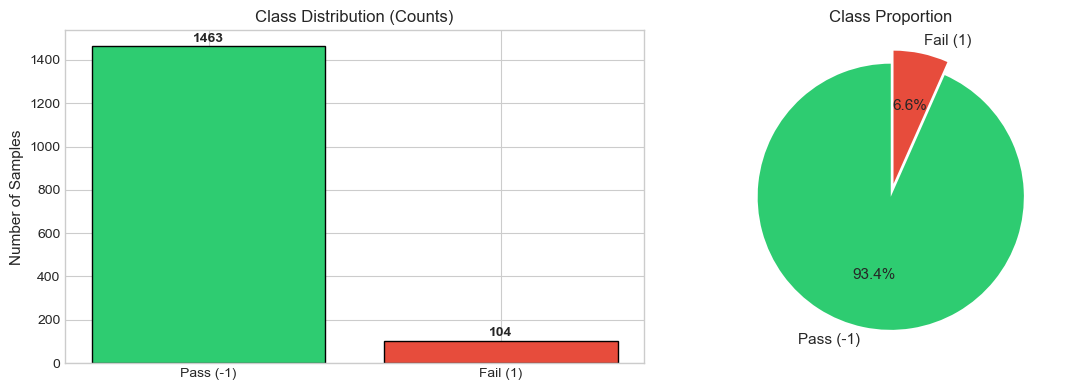

In [25]:
# Two Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Define colors: green for pass, red for fail
colors = ["#2ecc71", "#e74c3c"]
labels_text = ["Pass (-1)", "Fail (1)"]

# LEFT: Bar chart showing absolute counts
axes[0].bar(labels_text, [label_counts[-1], label_counts[1]], color=colors, edgecolor="black")
axes[0].set_ylabel("Number of Samples", fontsize=11)
axes[0].set_title("Class Distribution (Counts)", fontsize=12)
# Add count labels on top of bars
for i, v in enumerate([label_counts[-1], label_counts[1]]):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# RIGHT: Pie chart showing proportions
axes[1].pie(
    [label_counts[-1], label_counts[1]],
    labels=labels_text,
    autopct="%1.1f%%",
    colors=colors,
    explode=(0, 0.1),  # Emphasize the minority class
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title("Class Proportion", fontsize=12)

plt.tight_layout()
plt.show()

***
## 6. Feature Distribution Analysis

Comparing feature distributions between pass and fail samples helps identify:
- **Discriminative features**: Features that differ between classes
- **Distribution shapes**: Normal, skewed, bimodal, etc.
- **Overlap**: How separable the classes are in feature space

We focus on features with low missing values (<5%) to get reliable distribution estimates.

In [26]:
# Get features with less than 5% missing data
low_missing_features = missing_df[missing_df["missing_pct"] < 5].index.tolist()[:20]

print(f"Analyzing {len(low_missing_features)} features with <5% missing values")

Analyzing 20 features with <5% missing values


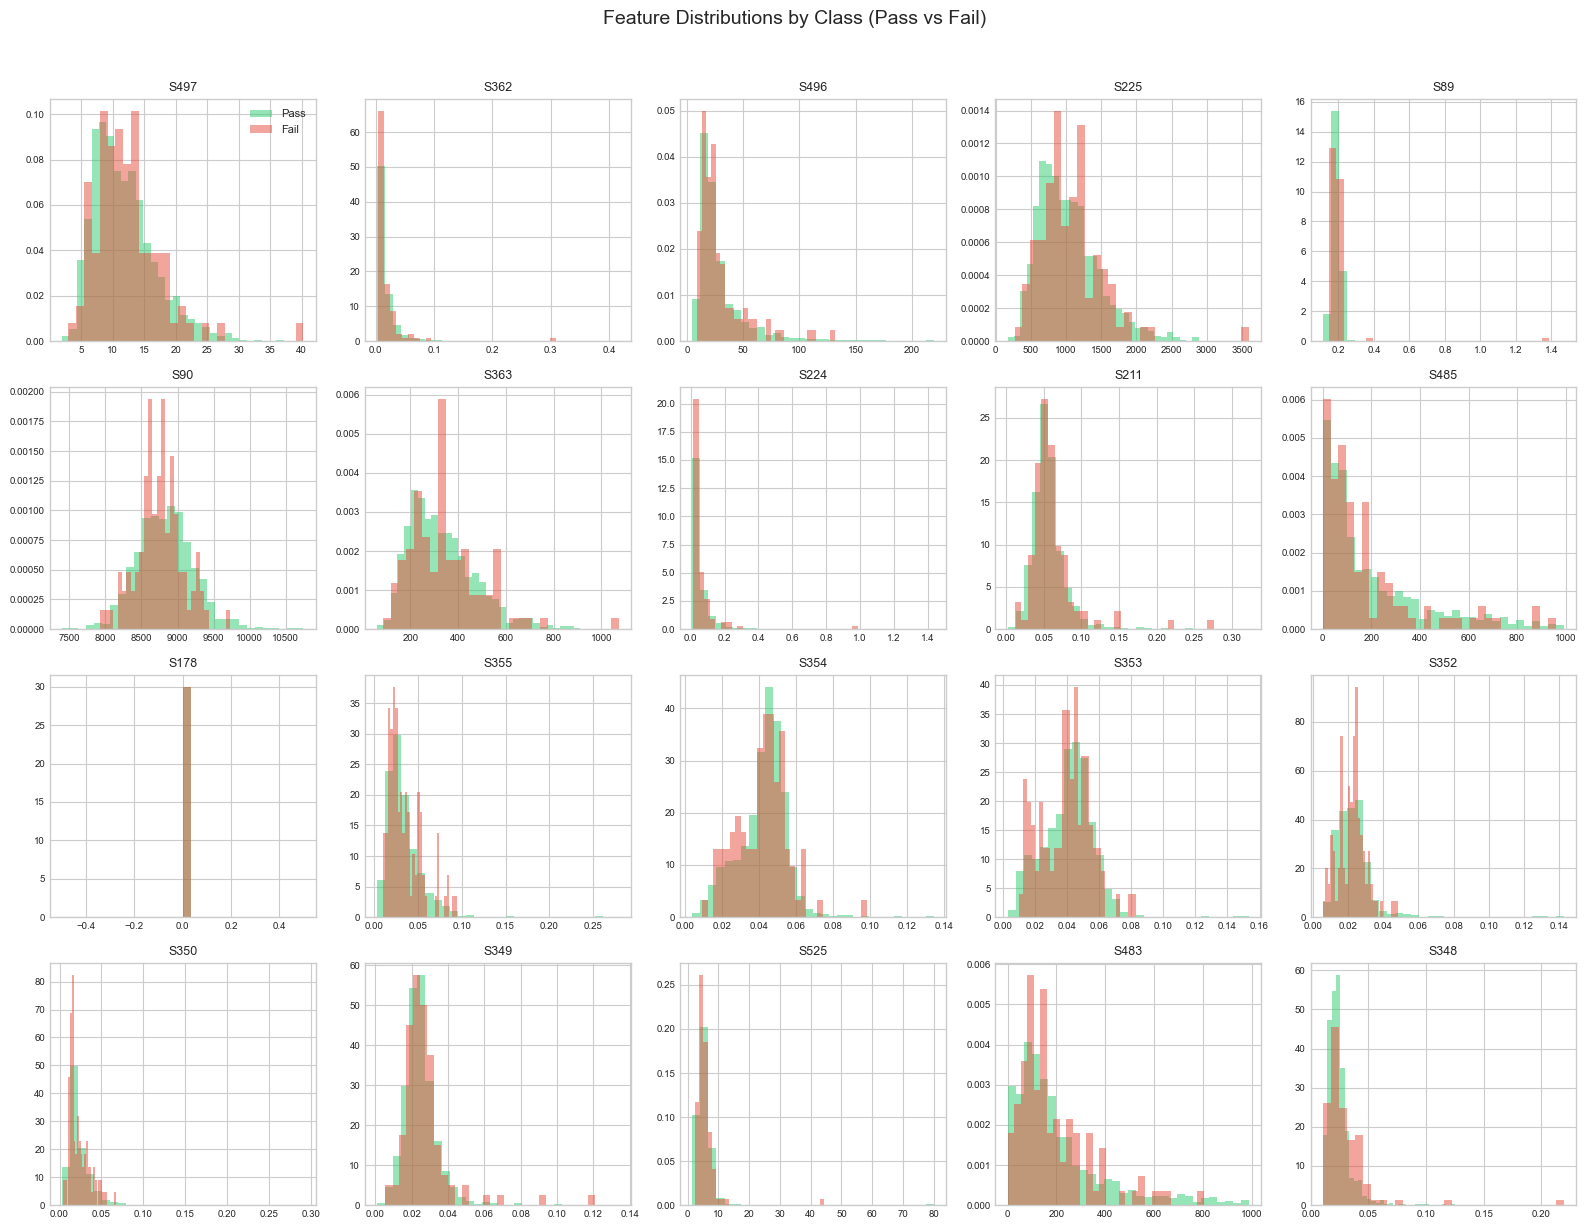

Look for features where the red and green distributions differ significantly - these are potentially predictive features.


In [27]:
# plot features with low missing values
fig, axes = plt.subplots(4, 5, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(low_missing_features):
    ax = axes[i]
    
    # Plot overlapping histograms for each class
    for label_val, color, label_name in [(-1, "#2ecc71", "Pass"), (1, "#e74c3c", "Fail")]:
        data = df[df["label"] == label_val][feature].dropna()
        ax.hist(data, bins=30, alpha=0.5, color=color, label=label_name, density=True)
    
    # Use shortened names for readability
    ax.set_title(feature.replace("sensor_", "S"), fontsize=9)
    ax.tick_params(labelsize=7)

# Add legend to first subplot only
axes[0].legend(fontsize=8)

plt.suptitle("Feature Distributions by Class (Pass vs Fail)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Look for features where the red and green distributions differ significantly - these are potentially predictive features.")

***
## 7. Correlation Analysis

Correlation analysis serves two purposes:
1. **Feature-to-feature correlation**: Identify redundant features that measure the same thing
2. **Feature-to-label correlation**: Find features most associated with the outcome

We use features with <10% missing to ensure reliable correlations.
Limiting to 50 features keeps the heatmap readable.

In [28]:
# Select features for correlation analysis
analysis_features = missing_df[missing_df["missing_pct"] < 10].index.tolist()[:50]

# Compute Pearson correlation matrix
corr_matrix = df[analysis_features].corr()

print(f"Computing correlations for {len(analysis_features)} features")
print(f"Correlation matrix shape: {corr_matrix.shape}")

Computing correlations for 50 features
Correlation matrix shape: (50, 50)


# CORRELATION HEATMAP

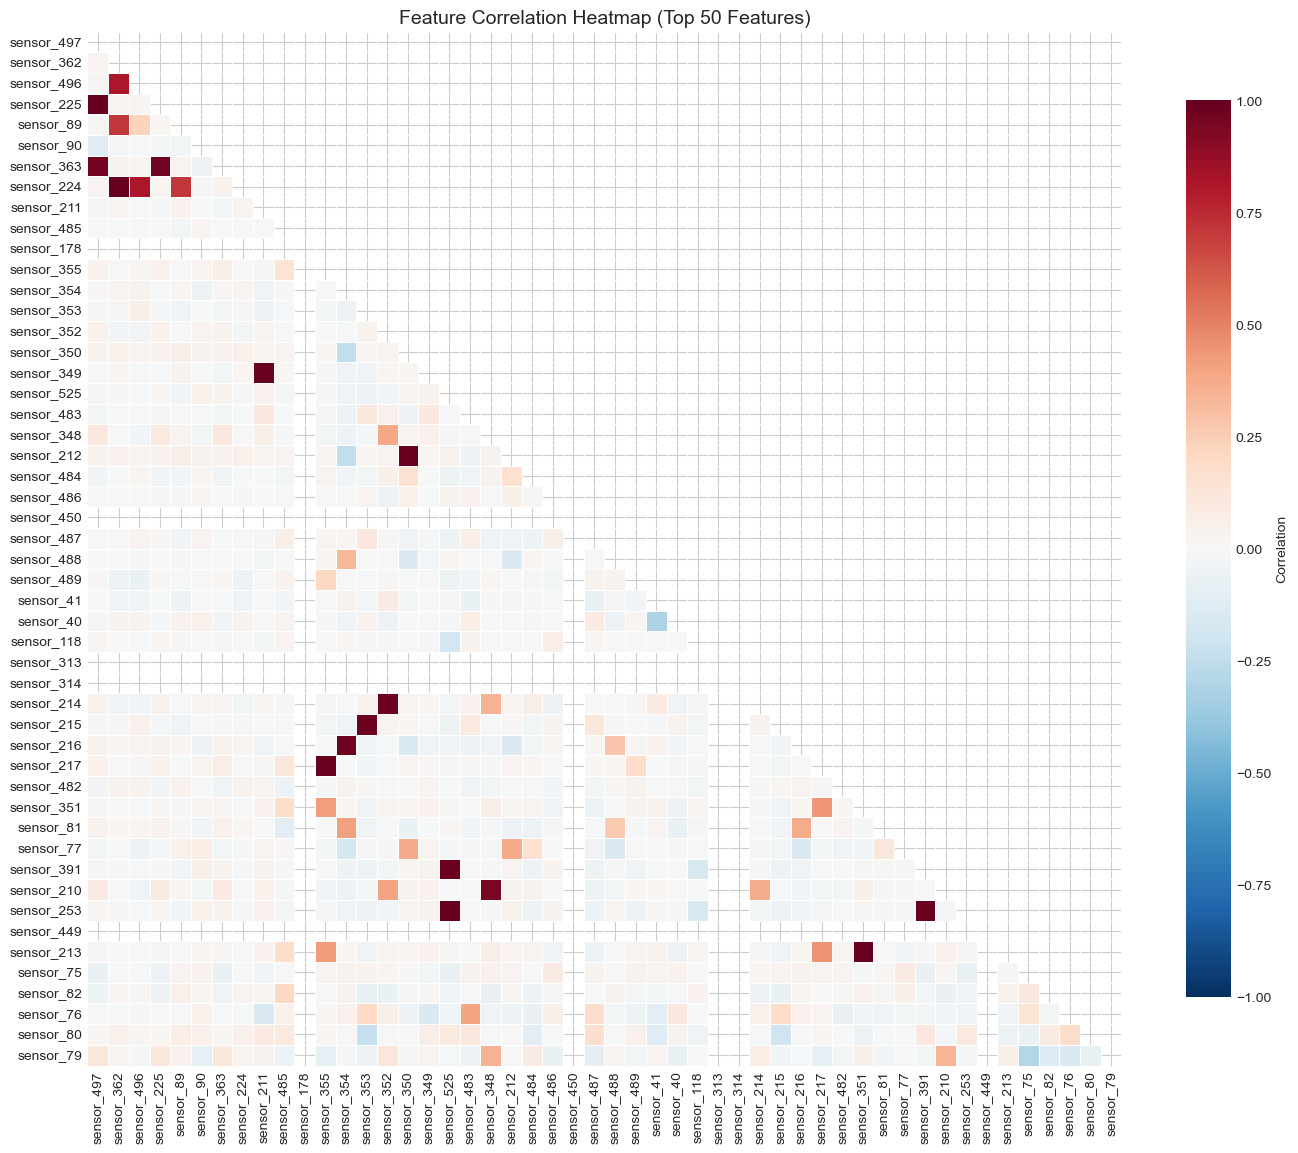

In [29]:
plt.figure(figsize=(14, 12))

# Create mask for upper triangle (avoid redundant info)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",  # Red-Blue diverging colormap
    center=0,       # Center colormap at 0
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
)

plt.title("Feature Correlation Heatmap (Top 50 Features)", fontsize=14)
plt.tight_layout()
plt.show()


Insight: Blocks of red/blue indicate groups of correlated features. These could be reduced using PCA or by removing redundant features.

In [30]:
#High Correlation pairs
# Find all pairs with correlation > 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append({
                "feature_1": corr_matrix.columns[i],
                "feature_2": corr_matrix.columns[j],
                "correlation": corr_val,
            })

# Create dataframe of highly correlated pairs
high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("correlation", ascending=False)

print(f"Found {len(high_corr_df)} highly correlated pairs (|r| > 0.9)")
print("\nTop 10 most correlated pairs:")
high_corr_df.head(10)

Found 15 highly correlated pairs (|r| > 0.9)

Top 10 most correlated pairs:


,feature_1,feature_2,correlation
11,sensor_525,sensor_253,0.999362
2,sensor_362,sensor_224,0.995710
13,sensor_351,sensor_213,0.995094
9,sensor_350,sensor_212,0.993534
0,sensor_497,sensor_225,0.993071
4,sensor_211,sensor_349,0.988676
5,sensor_355,sensor_217,0.987291
14,sensor_391,sensor_253,0.987185
10,sensor_525,sensor_391,0.986747
8,sensor_352,sensor_214,0.979281


# CORRELATION WITH TARGET LABEL
The most important correlations are with the target (pass/fail).
Features with high absolute correlation are likely predictive.

In [31]:
# Calculate correlation of each feature with the label
label_corr = df[feature_cols].corrwith(df["label"]).dropna()

# Sort by absolute correlation value
label_corr = label_corr.sort_values(key=abs, ascending=False)

print("Top 10 Features Most Correlated with Pass/Fail Label:")
for feat, corr in label_corr.head(10).items():
    direction = "↑ (higher = more fails)" if corr > 0 else "↓ (higher = more passes)"
    print(f"   {feat}: r = {corr:+.4f} {direction}")

Top 10 Features Most Correlated with Pass/Fail Label:
   sensor_59: r = +0.1558 ↑ (higher = more fails)
   sensor_103: r = +0.1512 ↑ (higher = more fails)
   sensor_510: r = +0.1316 ↑ (higher = more fails)
   sensor_348: r = +0.1302 ↑ (higher = more fails)
   sensor_158: r = +0.1213 ↑ (higher = more fails)
   sensor_431: r = +0.1209 ↑ (higher = more fails)
   sensor_293: r = +0.1145 ↑ (higher = more fails)
   sensor_111: r = -0.1139 ↓ (higher = more passes)
   sensor_434: r = +0.1121 ↑ (higher = more fails)
   sensor_430: r = +0.1101 ↑ (higher = more fails)


# VISUALIZE TOP CORRELATED FEATURES WITH LABEL

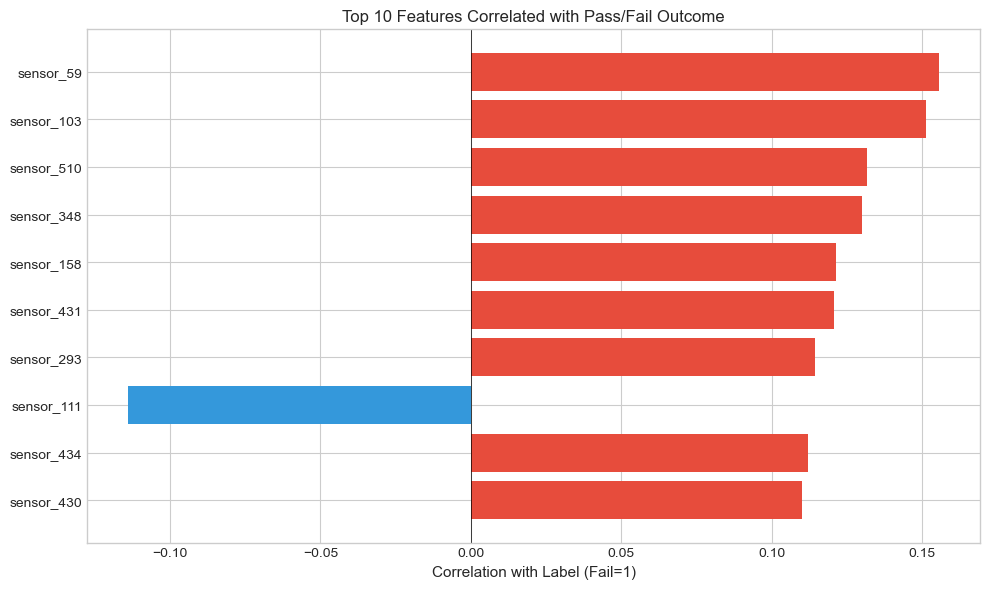

Insight: Red bars = higher values predict FAILURE.Blue bars = higher values predict PASS


In [32]:
top_corr_features = label_corr.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))

# Color by direction: red for positive, blue for negative
colors = ["#e74c3c" if x > 0 else "#3498db" for x in label_corr.head(10).values]

ax.barh(range(10), label_corr.head(10).values, color=colors)
ax.set_yticks(range(10))
ax.set_yticklabels(top_corr_features)
ax.set_xlabel("Correlation with Label (Fail=1)", fontsize=11)
ax.set_title("Top 10 Features Correlated with Pass/Fail Outcome", fontsize=12)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("Insight: Red bars = higher values predict FAILURE.Blue bars = higher values predict PASS")

***
## 8. Outlier Detection

Outliers in sensor data may represent:
- **Genuine anomalies**: Unusual but valid measurements
- **Sensor errors**: Malfunctions or calibration issues  
- **Data entry errors**: Mistakes during data collection

We use the **Interquartile Range (IQR) method** to identify outliers.

IQR Method:
Q1 = 25th percentile, Q3 = 75th percentile
IQR = Q3 - Q1 (middle 50% of data)
Outliers: values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR

In [33]:
# Function to count outliers using IQR method
def count_outliers_iqr(series):
    """
    Count the number of outliers in a pandas Series using IQR method.
    
    Parameters:
        series: pandas Series of numeric values
        
    Returns:
        int: Number of outlier values
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((series < lower_bound) | (series > upper_bound)).sum()


# Count outliers for each feature with low missing values
outlier_counts = {}
for col in low_missing_features:
    outlier_counts[col] = count_outliers_iqr(df[col].dropna())

# Create summary dataframe
outlier_df = pd.DataFrame({
    "outlier_count": outlier_counts.values(),
    "outlier_pct": [c / len(df) * 100 for c in outlier_counts.values()],
}, index=outlier_counts.keys()).sort_values("outlier_pct", ascending=False)

print("Outlier Analysis Summary")
print(f"Average outlier percentage: {outlier_df['outlier_pct'].mean():.1f}%")
print(f"Max outlier percentage:     {outlier_df['outlier_pct'].max():.1f}%")
print("\nFeatures with most outliers:")
outlier_df.head(10)

Outlier Analysis Summary
Average outlier percentage: 4.4%
Max outlier percentage:     10.5%

Features with most outliers:


,outlier_count,outlier_pct
sensor_362,165,10.529675
sensor_224,153,9.763880
sensor_496,149,9.508615
sensor_483,122,7.785578
sensor_485,104,6.636886
sensor_348,100,6.381621
sensor_211,77,4.913848
sensor_349,72,4.594767
sensor_355,72,4.594767
sensor_350,67,4.275686


# BOX PLOTS FOR FEATURES WITH MOST OUTLIERS
Box plots show the distribution and outliers by class, helping us see if outliers are associated with failures.

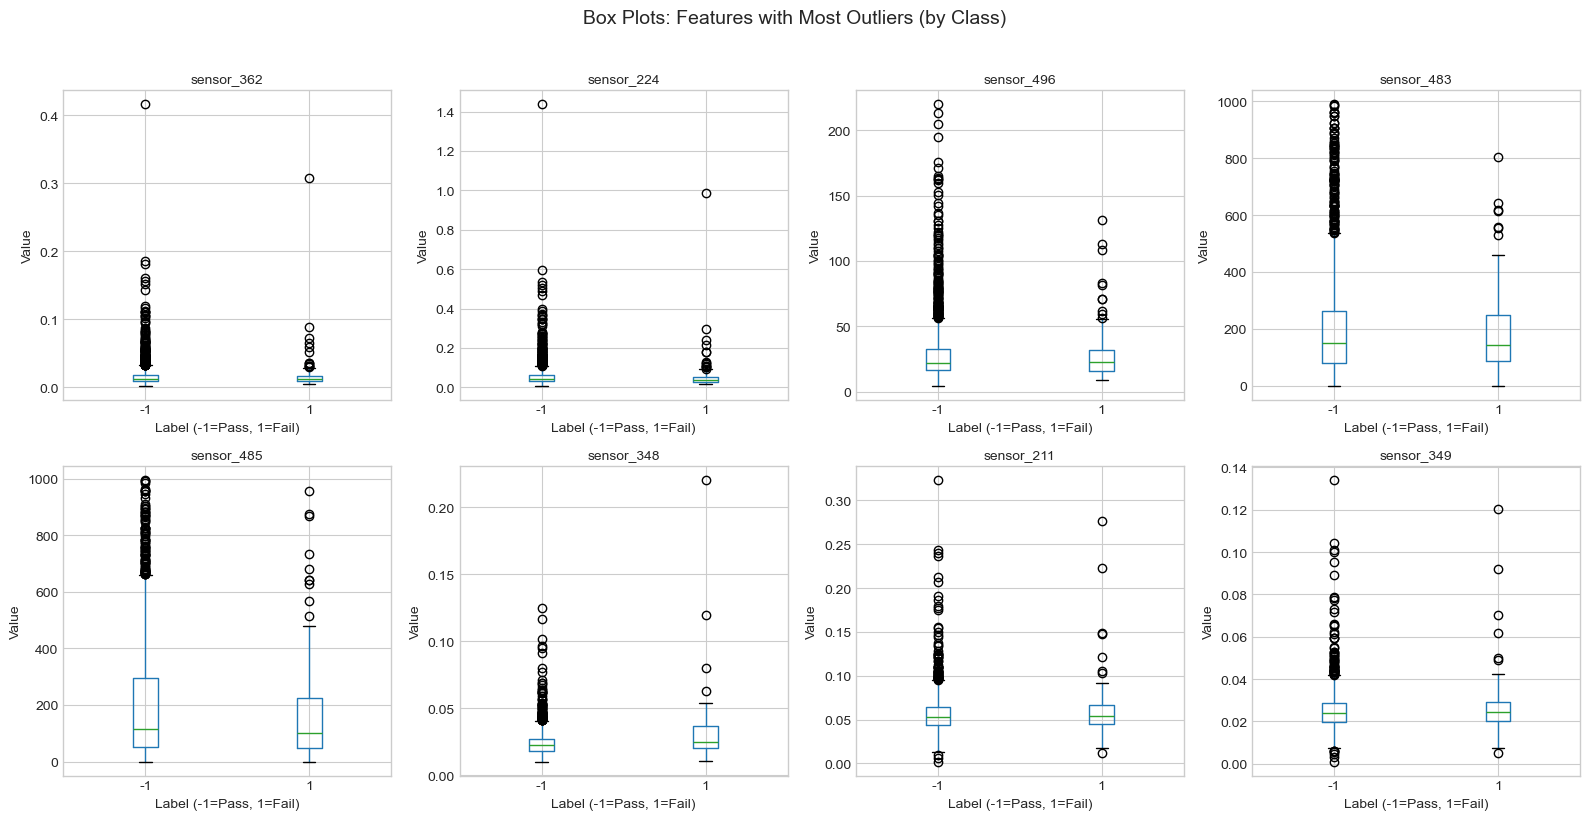

Insight: Outliers that appear only in one class may be important predictive signals rather than errors.


In [34]:

top_outlier_features = outlier_df.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(top_outlier_features):
    ax = axes[i]
    df.boxplot(column=feature, by="label", ax=ax)
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel("Label (-1=Pass, 1=Fail)")
    ax.set_ylabel("Value")

plt.suptitle("Box Plots: Features with Most Outliers (by Class)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Insight: Outliers that appear only in one class may be important predictive signals rather than errors.")

***
## 9. Key Findings Summary


# SECOM EDA - KEY FINDINGS REPORT


 DATASET OVERVIEW
   • Total samples:          1,567
   • Sensor features:        590
   • Data collection period: 89 days

  MISSING VALUES
   • Features with missing data:    538 (91.2%)
   • Features with >50% missing:    28
   • Avg missing per sample:        27 features
   → ACTION: Impute or remove features with >50% missing

  CLASS IMBALANCE
   • Pass samples:   1,463 (93.4%)
   • Fail samples:   104 (6.6%)
   • Imbalance ratio: 14.1:1
   → ACTION: Use SMOTE, class weights, or stratified sampling

 FEATURE REDUNDANCY
   • Highly correlated pairs (|r|>0.9): 15
   • Constant (zero variance) features: 116
   • Near-zero variance features:       171
   → ACTION: Remove constant features; consider PCA

 TOP PREDICTIVE FEATURES
   • Best correlated with outcome: sensor_59
     Correlation: r = 0.1558
   → These features should be prioritized in modeling




***
## 10. Preprocessing Recommendations

Based on this exploratory analysis, the following preprocessing pipeline is recommended before building predictive models:

### Step 1: Handle Missing Values
| Action | Criteria | Rationale |
|--------|----------|----------|
| **Remove features** | >50% missing | Too much missing data to impute reliably |
| **Impute remaining** | <50% missing | Use median imputation (robust to outliers) |

### Step 2: Feature Selection
- **Remove constant features** (zero variance) - provide no information
- **Address multicollinearity** - remove one of each highly correlated pair (|r| > 0.95)
- Consider **PCA** for dimensionality reduction

### Step 3: Handle Class Imbalance
Choose one or more approaches:
- **SMOTE** (Synthetic Minority Over-sampling Technique)
- **Class weights** in model training (e.g., `class_weight='balanced'`)
- **Stratified sampling** for train/test splits

### Step 4: Outlier Treatment
- Use **RobustScaler** instead of StandardScaler (less sensitive to outliers)
- Investigate outliers that appear only in failure samples (potential predictive signals)

### Step 5: Feature Scaling
- **Standardize all features** before modeling (sensors have different scales)
- This is essential for distance-based algorithms (KNN, SVM) and neural networks